In [2]:
import numpy as np
import matplotlib.pyplot as plt
import abp

dr = 0.05
mu = 0.0
dt = 0.01
tmax = 300.0

ens = 10000
n = int(tmax/dt)
ntimes = 500

xstore = np.zeros((ens, ntimes), dtype=np.float32, order="F")
ystore = np.zeros((ens, ntimes), dtype=np.float32, order="F")
cstore = np.zeros((ens, ntimes), dtype=np.float32, order="F")
sstore = np.zeros((ens, ntimes), dtype=np.float32, order="F")
times  = np.zeros(ntimes, dtype=np.float32, order="F")

xstore, ystore, cstore, sstore, times = abp.abp_store(dr, mu, dt, ens, n, ntimes, xstore, ystore, cstore, sstore, times)

In [3]:
avgx = np.mean(xstore, axis=0)
avgy = np.mean(ystore, axis=0)

avgx2 = np.mean(xstore**2, axis=0)
avgy2 = np.mean(ystore**2, axis=0)

msd = avgx2 + avgy2

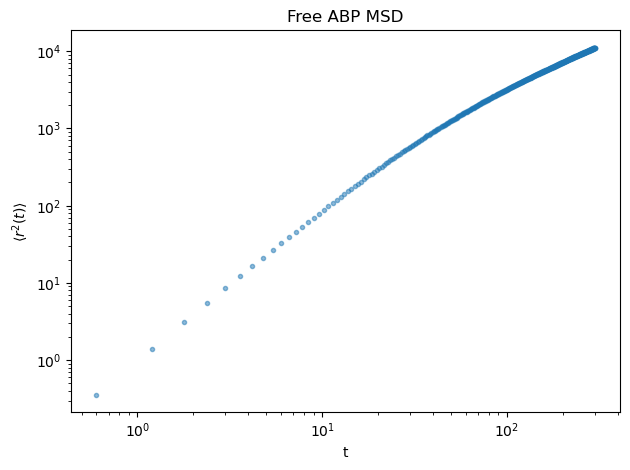

In [4]:
plt.loglog(times, msd, 'o', ms=3, alpha=0.5)
plt.xlabel("t")
plt.ylabel(r"$\langle r^2(t)\rangle$")
plt.title("Free ABP MSD")
plt.tight_layout()
plt.show()

In [12]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

ntimes = xstore.shape[1]

xmin, xmax = xstore.min(), xstore.max()
ymin, ymax = ystore.min(), ystore.max()

fig, ax = plt.subplots()

h = ax.hist2d(xstore[:,0], ystore[:,0], bins=100, density=True, range=[[xmin,xmax],[ymin,ymax]])
cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("Particle density")
def update(frame):
    ax.clear()
    h = ax.hist2d(xstore[:,frame], ystore[:,frame], bins=100, density=True, range=[[xmin,xmax],[ymin,ymax]])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"t = {times[frame]:.2f}")
    return h[3], 
    
ani = FuncAnimation(fig, update, frames=range(0, ntimes, 10), interval=100)

plt.close(fig)

HTML(ani.to_jshtml())